# GraphletMatchMaker-Based EDA for VAST 2020 Mini-Challenge Data

This notebook completes the exploratory data analysis using the methodology described in `GraphletMatchMaker.pdf`:

1. Compare graph structure with node-link summaries.
2. Compare person-to-person graphlet frequencies.
3. Compare temporal activity profiles and best time shifts.
4. Compare person profiles using financial/demographic, travel, and procurement layers.

The goal is to determine which `Q1-Graph*` candidate is closest to `CGCS-Template`.

## 1. Setup and Data Loading

The PDF describes a directed, temporal, multi-relational graph with person nodes at the center of several layers:

| eType | Layer | Meaning |
|---:|---|---|
| 0 | Communication | Email |
| 1 | Communication | Phone |
| 2 | Procurement | Sell |
| 3 | Procurement | Buy |
| 4 | Publication | Author-of |
| 5 | Demographic/Financial | Financial category profile |
| 6 | Travel | Travels-to country |

Node types:

| NodeType | Meaning |
|---:|---|
| 1 | Person |
| 2 | Product category |
| 3 | Document |
| 4 | Financial category |
| 5 | Country |

In [1]:
from pathlib import Path
from itertools import combinations, permutations
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

CWD = Path.cwd().resolve()
ROOT = CWD.parent if CWD.name == 'src' else CWD
DATA_DIR = ROOT / 'data'

EDGE_TYPE_LABELS = {
    0: 'Email',
    1: 'Phone',
    2: 'Sell',
    3: 'Buy',
    4: 'Author-of',
    5: 'Financial',
    6: 'Travels-to',
}

NODE_TYPE_LABELS = {
    '1': 'Person',
    '2': 'Product category',
    '3': 'Document',
    '4': 'Financial category',
    '5': 'Country',
}

GRAPH_FILES = {
    'Template': 'CGCS-Template.csv',
    'Q1_Graph1': 'Q1-Graph1.csv',
    'Q1_Graph2': 'Q1-Graph2.csv',
    'Q1_Graph3': 'Q1-Graph3.csv',
    'Q1_Graph4': 'Q1-Graph4.csv',
    'Q1_Graph5': 'Q1-Graph5.csv',
}

SEED_FILES = {
    'Q2_Seed1': 'Q2-Seed1.csv',
    'Q2_Seed2': 'Q2-Seed2.csv',
    'Q2_Seed3': 'Q2-Seed3.csv',
}

graphs = {name: pd.read_csv(DATA_DIR / filename) for name, filename in GRAPH_FILES.items()}
seeds = {name: pd.read_csv(DATA_DIR / filename) for name, filename in SEED_FILES.items()}

global_node_types = pd.read_csv(DATA_DIR / 'CGCS-GraphData-NodeTypes.csv').astype(str)
template_node_types = pd.read_csv(DATA_DIR / 'CGCS-Template-NodeTypes.csv').astype(str)
node_type_descriptions = pd.read_csv(DATA_DIR / 'NodeTypeDescriptions.csv')
demographic_categories = pd.read_csv(DATA_DIR / 'DemographicCategories.csv').astype(str)

global_type_map = dict(zip(global_node_types['NodeID'], global_node_types['NodeType']))
template_type_map = dict(zip(template_node_types['NodeID'], template_node_types['NodeType']))

for df in graphs.values():
    for col in ['Source', 'Target']:
        df[col] = df[col].astype(str)
    for col in ['eType', 'Time', 'Weight']:
        df[col] = pd.to_numeric(df[col], errors='coerce')

print('Loaded graphs:', list(graphs))
print('Loaded seeds:', list(seeds))

Loaded graphs: ['Template', 'Q1_Graph1', 'Q1_Graph2', 'Q1_Graph3', 'Q1_Graph4', 'Q1_Graph5']
Loaded seeds: ['Q2_Seed1', 'Q2_Seed2', 'Q2_Seed3']


## 2. Inventory and Data Quality

Before comparing candidate graphs to the template, inspect size, schema, missingness, edge type distributions, node type coverage, temporal sentinels, and weight anomalies.

In [2]:
def graph_node_ids(df):
    return pd.unique(df[['Source', 'Target']].values.ravel())

def node_type_map_for_graph(name):
    return template_type_map if name == 'Template' else global_type_map

def graph_summary(name, df):
    node_ids = graph_node_ids(df)
    type_map = node_type_map_for_graph(name)
    mapped_types = pd.Series([type_map.get(str(n), 'Unknown') for n in node_ids])
    G = nx.DiGraph()
    for row in df.itertuples(index=False):
        G.add_edge(row.Source, row.Target)
    weak_components = list(nx.weakly_connected_components(G))
    return {
        'graph': name,
        'rows_edges': len(df),
        'unique_nodes': len(node_ids),
        'density': nx.density(G),
        'weak_components': len(weak_components),
        'largest_component_nodes': max(map(len, weak_components)) if weak_components else 0,
        'self_loops': int((df['Source'] == df['Target']).sum()),
        'duplicate_source_target_etype_rows': int(df.duplicated(['Source', 'Target', 'eType']).sum()),
        'negative_time_rows': int((df['Time'] < 0).sum()),
        'day365_rows': int((df['Time'] == 31_536_000).sum()),
        'negative_weight_rows': int((df['Weight'] < 0).sum()),
        'zero_weight_rows': int((df['Weight'] == 0).sum()),
        'location_rows': int((df['SourceLocation'].notna() & (df['SourceLocation'].astype(str) != '') | df['TargetLocation'].notna() & (df['TargetLocation'].astype(str) != '')).sum()),
        'unknown_node_type_count': int((mapped_types == 'Unknown').sum()),
    }

summary_df = pd.DataFrame([graph_summary(name, df) for name, df in graphs.items()])
summary_df

,graph,rows_edges,unique_nodes,density,weak_components,largest_component_nodes,self_loops,duplicate_source_target_etype_rows,negative_time_rows,day365_rows,negative_weight_rows,zero_weight_rows,location_rows,unknown_node_type_count
0,Template,1325,88,0.112200,1,88,0,413,1,691,1,0,301,0
1,Q1_Graph1,1216,93,0.114423,1,93,0,209,1,846,0,0,168,0
2,Q1_Graph2,1300,87,0.127239,1,87,0,314,4,823,0,0,201,0
3,Q1_Graph3,729,79,0.098345,1,79,0,110,1,519,0,0,88,0
4,Q1_Graph4,732,87,0.082197,1,87,4,111,0,494,45,0,176,0
5,Q1_Graph5,395,86,0.038988,1,86,0,106,0,203,30,15,124,0


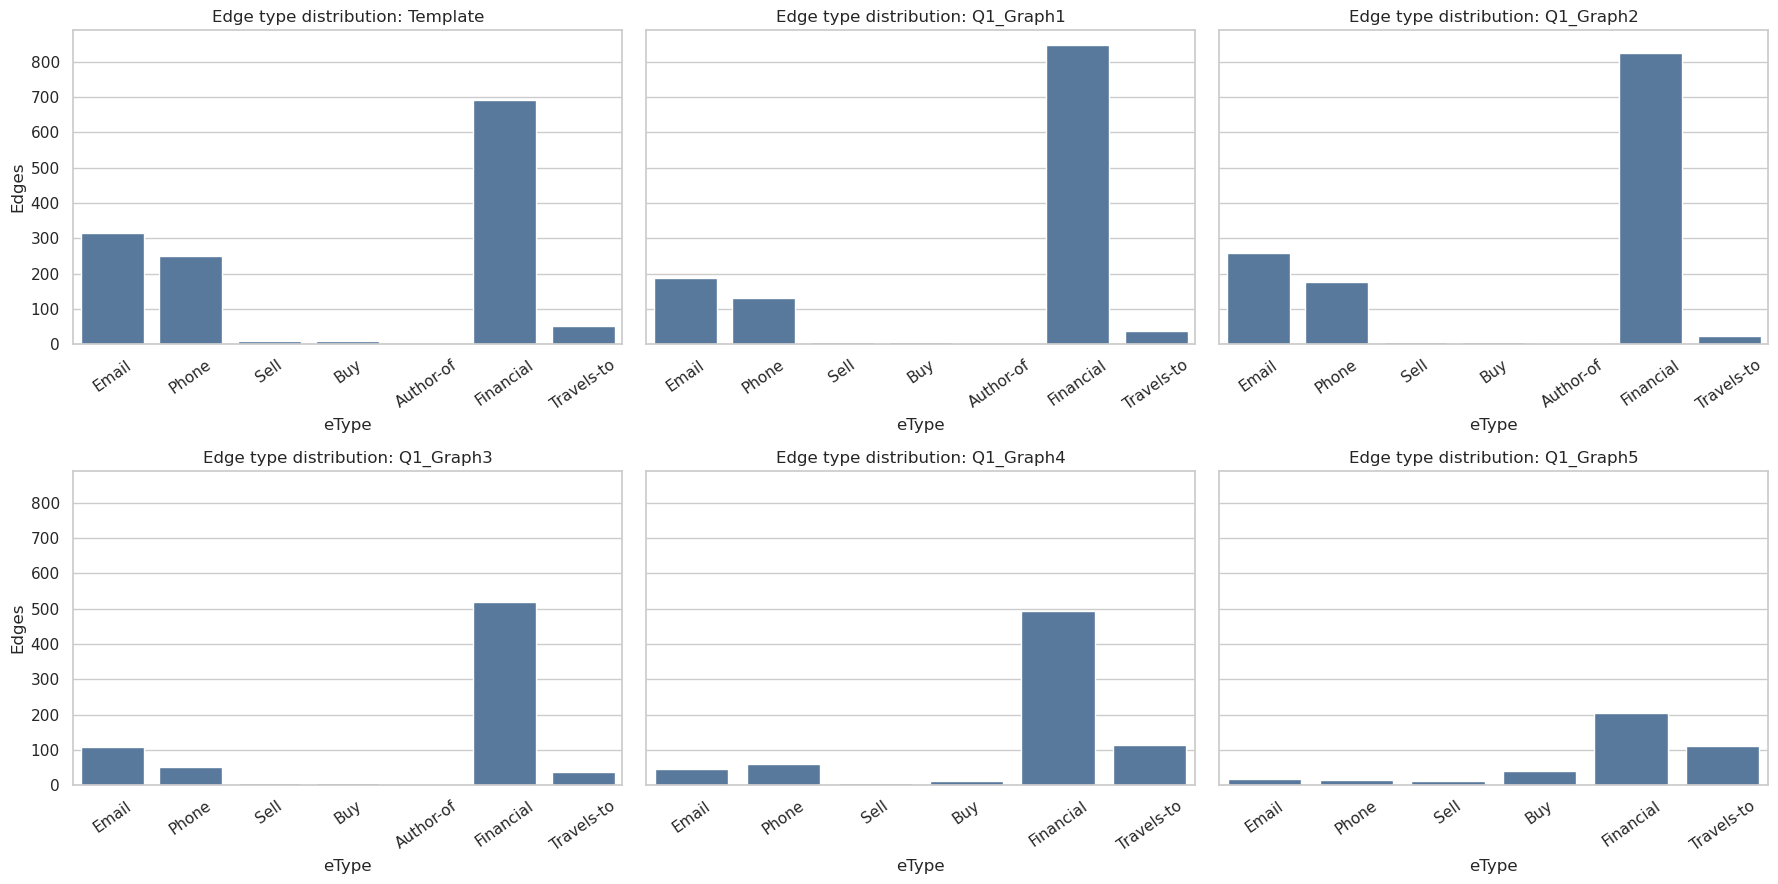

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(18, 9), sharey=True)
axes = axes.ravel()
for ax, (name, df) in zip(axes, graphs.items()):
    counts = df['eType'].value_counts().sort_index()
    labels = [EDGE_TYPE_LABELS.get(int(i), str(i)) for i in counts.index]
    sns.barplot(x=labels, y=counts.values, ax=ax, color='#4C78A8')
    ax.set_title(f'Edge type distribution: {name}')
    ax.set_xlabel('eType')
    ax.set_ylabel('Edges')
    ax.tick_params(axis='x', rotation=35)
plt.tight_layout()
plt.show()

In [4]:
def node_type_counts(name, df):
    ids = graph_node_ids(df)
    type_map = node_type_map_for_graph(name)
    counts = Counter(type_map.get(str(n), 'Unknown') for n in ids)
    return {
        'graph': name,
        **{NODE_TYPE_LABELS.get(k, k): v for k, v in sorted(counts.items())}
    }

node_type_count_df = pd.DataFrame([node_type_counts(name, df) for name, df in graphs.items()]).fillna(0)
node_type_count_df

,graph,Person,Product category,Document,Financial category,Country
0,Template,51,1,1.0,29,6
1,Q1_Graph1,56,1,1.0,29,6
2,Q1_Graph2,49,1,4.0,29,4
3,Q1_Graph3,42,1,1.0,29,6
4,Q1_Graph4,39,13,0.0,29,6
5,Q1_Graph5,10,41,0.0,29,6


## 3. Node-Link Structure Summaries

The PDF first compares template and candidates with node-link diagrams. Static notebook rendering is dense, so this section uses compact structure diagnostics:

- node and edge counts,
- density and components,
- communication hubs,
- edge type by source/target node type,
- repeated directed relations.

In [5]:
def relation_type_table(name, df):
    type_map = node_type_map_for_graph(name)
    rows = []
    for row in df.itertuples(index=False):
        st = NODE_TYPE_LABELS.get(type_map.get(row.Source, 'Unknown'), 'Unknown')
        tt = NODE_TYPE_LABELS.get(type_map.get(row.Target, 'Unknown'), 'Unknown')
        rows.append((name, int(row.eType), EDGE_TYPE_LABELS.get(int(row.eType), str(row.eType)), st, tt))
    return pd.DataFrame(rows, columns=['graph', 'eType', 'edge_label', 'source_type', 'target_type'])

relation_df = pd.concat([relation_type_table(name, df) for name, df in graphs.items()], ignore_index=True)
relation_summary = (
    relation_df
    .groupby(['graph', 'eType', 'edge_label', 'source_type', 'target_type'])
    .size()
    .reset_index(name='edges')
    .sort_values(['graph', 'eType', 'edges'], ascending=[True, True, False])
)
relation_summary

,graph,eType,edge_label,source_type,target_type,edges
0,Q1_Graph1,0,Email,Person,Person,187
1,Q1_Graph1,1,Phone,Person,Person,131
2,Q1_Graph1,2,Sell,Person,Product category,7
3,Q1_Graph1,3,Buy,Person,Product category,7
4,Q1_Graph1,4,Author-of,Person,Document,1
6,Q1_Graph1,5,Financial,Person,Financial category,764
5,Q1_Graph1,5,Financial,Financial category,Person,82
7,Q1_Graph1,6,Travels-to,Person,Country,37
8,Q1_Graph2,0,Email,Person,Person,258
9,Q1_Graph2,1,Phone,Person,Person,177


In [6]:
def communication_graph(df):
    G = nx.Graph()
    comm = df[df['eType'].isin([0, 1])]
    for row in comm.itertuples(index=False):
        G.add_edge(row.Source, row.Target)
    return G

hub_rows = []
for name, df in graphs.items():
    G = communication_graph(df)
    for node, degree in sorted(G.degree(), key=lambda x: x[1], reverse=True)[:10]:
        hub_rows.append({'graph': name, 'node': node, 'communication_degree': degree})

communication_hubs = pd.DataFrame(hub_rows)
communication_hubs

,graph,node,communication_degree
0,Template,41,14
1,Template,47,11
2,Template,37,10
3,Template,27,10
4,Template,43,10
5,Template,56,10
6,Template,57,10
7,Template,58,10
8,Template,63,10
9,Template,45,10


## 4. Graphlet Frequency Comparison

The paper compares graphlet frequencies on person-to-person relationships. Here, the induced graphlets are computed on an undirected communication graph made from `Email` and `Phone` edges (`eType` 0 and 1). Small connected graphlets of size 2 to 4 are counted.

The graphlet distance is the L1 distance between normalized graphlet-frequency vectors. Lower means closer to the template.

In [7]:
def canonical_graphlet_key(H):
    nodes = list(H.nodes())
    n = len(nodes)
    best = None
    for perm in permutations(nodes):
        bits = []
        for i in range(n):
            for j in range(i + 1, n):
                bits.append('1' if H.has_edge(perm[i], perm[j]) else '0')
        candidate = ''.join(bits)
        if best is None or candidate < best:
            best = candidate
    return f'n{n}:{best}'


def graphlet_counts(df, kmax=4):
    G = communication_graph(df)
    counts = Counter()
    nodes = list(G.nodes())
    for k in range(2, kmax + 1):
        for subset in combinations(nodes, k):
            H = G.subgraph(subset)
            if H.number_of_edges() > 0 and nx.is_connected(H):
                counts[canonical_graphlet_key(H)] += 1
    return counts, G


def normalized_l1_distance(c1, c2):
    keys = sorted(set(c1) | set(c2))
    a = np.array([c1.get(k, 0) for k in keys], dtype=float)
    b = np.array([c2.get(k, 0) for k in keys], dtype=float)
    if a.sum() > 0:
        a = a / a.sum()
    if b.sum() > 0:
        b = b / b.sum()
    return float(np.abs(a - b).sum() / 2)

template_graphlets, template_comm_graph = graphlet_counts(graphs['Template'])

graphlet_rows = []
for name, df in graphs.items():
    counts, G = graphlet_counts(df)
    graphlet_rows.append({
        'graph': name,
        'communication_nodes': G.number_of_nodes(),
        'communication_edges': G.number_of_edges(),
        'graphlet_l1_distance_to_template': normalized_l1_distance(template_graphlets, counts),
        **counts,
    })

graphlet_df = pd.DataFrame(graphlet_rows).fillna(0)
graphlet_df[['graph', 'communication_nodes', 'communication_edges', 'graphlet_l1_distance_to_template']].sort_values('graphlet_l1_distance_to_template')

,graph,communication_nodes,communication_edges,graphlet_l1_distance_to_template
0,Template,17,67,0.000000
2,Q1_Graph2,18,62,0.237415
3,Q1_Graph3,14,31,0.284830
1,Q1_Graph1,20,63,0.307590
5,Q1_Graph5,10,25,0.512328
4,Q1_Graph4,39,82,0.624083


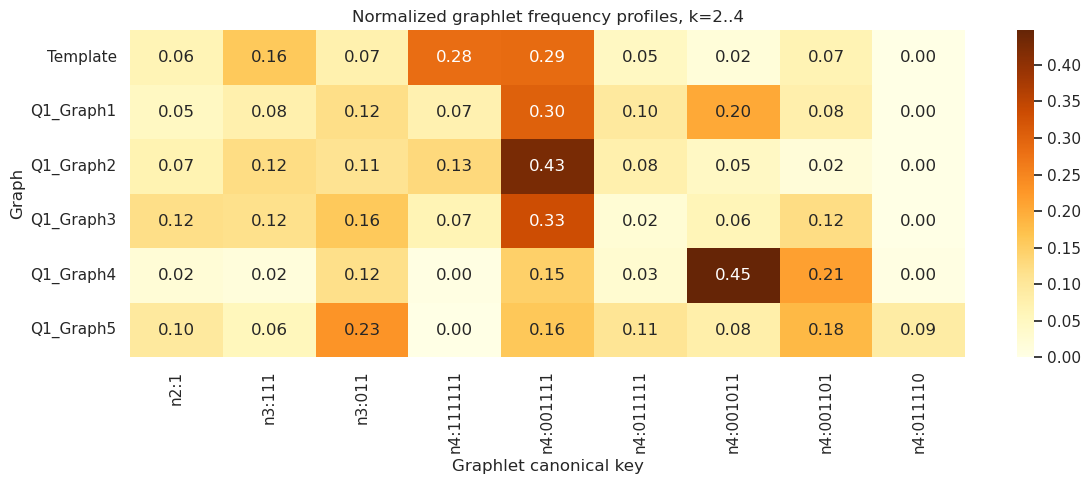

In [8]:
graphlet_cols = [c for c in graphlet_df.columns if c.startswith('n')]
plot_df = graphlet_df.set_index('graph')[graphlet_cols]
plot_df_norm = plot_df.div(plot_df.sum(axis=1), axis=0).fillna(0)

plt.figure(figsize=(12, 5))
sns.heatmap(plot_df_norm, cmap='YlOrBr', annot=True, fmt='.2f')
plt.title('Normalized graphlet frequency profiles, k=2..4')
plt.xlabel('Graphlet canonical key')
plt.ylabel('Graph')
plt.tight_layout()
plt.show()

## 5. Temporal Profile Comparison

The PDF compares temporal activity profiles with stacked daily activity charts. This section computes daily counts and compares each candidate to the template using cosine distance after searching for the best lag from -30 to +30 days.

`Time = 31,536,000` corresponds to day 365 and appears mostly in financial edges, so the communication and travel temporal profiles are more informative than the all-edge profile.

In [9]:
def cosine_distance(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    n = max(len(a), len(b))
    a = np.pad(a, (0, n - len(a)))
    b = np.pad(b, (0, n - len(b)))
    na = np.linalg.norm(a)
    nb = np.linalg.norm(b)
    if na == 0 and nb == 0:
        return 0.0
    if na == 0 or nb == 0:
        return 1.0
    return float(1 - np.dot(a, b) / (na * nb))


def daily_counts(df, etypes=None):
    d = df.copy()
    if etypes is not None:
        d = d[d['eType'].isin(etypes)]
    d = d[(d['Time'] >= 0) & (d['Time'] <= 31_536_000)]
    day = (d['Time'] // 86_400).astype(int).clip(0, 365)
    return np.bincount(day, minlength=366).astype(float)


def shifted(arr, lag):
    arr = np.asarray(arr, dtype=float)
    if lag < 0:
        return np.r_[arr[-lag:], np.zeros(-lag)]
    if lag > 0:
        return np.r_[np.zeros(lag), arr[:-lag]]
    return arr.copy()


def best_lag_distance(template_arr, candidate_arr, max_lag=30):
    best_lag = 0
    best_distance = cosine_distance(template_arr, candidate_arr)
    for lag in range(-max_lag, max_lag + 1):
        d = cosine_distance(template_arr, shifted(candidate_arr, lag))
        if d < best_distance:
            best_lag = lag
            best_distance = d
    return best_lag, best_distance

LAYERS = {
    'all': None,
    'communication': [0, 1],
    'travel': [6],
    'financial': [5],
    'procurement': [2, 3],
}

temporal_rows = []
for layer, etypes in LAYERS.items():
    template_arr = daily_counts(graphs['Template'], etypes)
    for name, df in graphs.items():
        candidate_arr = daily_counts(df, etypes)
        lag, distance = best_lag_distance(template_arr, candidate_arr)
        peak_days = np.argsort(candidate_arr)[-5:][::-1]
        temporal_rows.append({
            'graph': name,
            'layer': layer,
            'best_lag_days': lag,
            'cosine_distance_to_template': distance,
            'top_activity_days': [(int(day), int(candidate_arr[day])) for day in peak_days if candidate_arr[day] > 0],
        })

temporal_df = pd.DataFrame(temporal_rows)
temporal_df.sort_values(['layer', 'cosine_distance_to_template']).reset_index(drop=True)

,graph,layer,best_lag_days,cosine_distance_to_template,top_activity_days
0,Template,all,0,0.000000e+00,"[(365, 691), (301, 23), (302, 17), (150, 14), ..."
1,Q1_Graph3,all,0,4.328614e-03,"[(365, 519), (111, 6), (64, 5), (122, 5), (68,..."
2,Q1_Graph1,all,0,4.390794e-03,"[(365, 846), (278, 12), (244, 10), (277, 8), (..."
3,Q1_Graph4,all,0,4.937006e-03,"[(365, 494), (328, 10), (314, 10), (19, 7), (1..."
4,Q1_Graph2,all,0,4.966484e-03,"[(365, 823), (290, 37), (15, 13), (291, 11), (..."
5,Q1_Graph5,all,0,9.731246e-03,"[(365, 203), (175, 10), (23, 6), (96, 6), (198..."
6,Template,communication,0,0.000000e+00,"[(301, 23), (302, 17), (150, 14), (144, 12), (..."
7,Q1_Graph2,communication,11,4.109509e-01,"[(290, 36), (15, 13), (291, 11), (20, 10), (19..."
8,Q1_Graph1,communication,24,5.116698e-01,"[(278, 12), (244, 8), (21, 8), (241, 8), (277,..."
9,Q1_Graph4,communication,22,6.747500e-01,"[(79, 3), (280, 3), (125, 3), (85, 2), (257, 2)]"


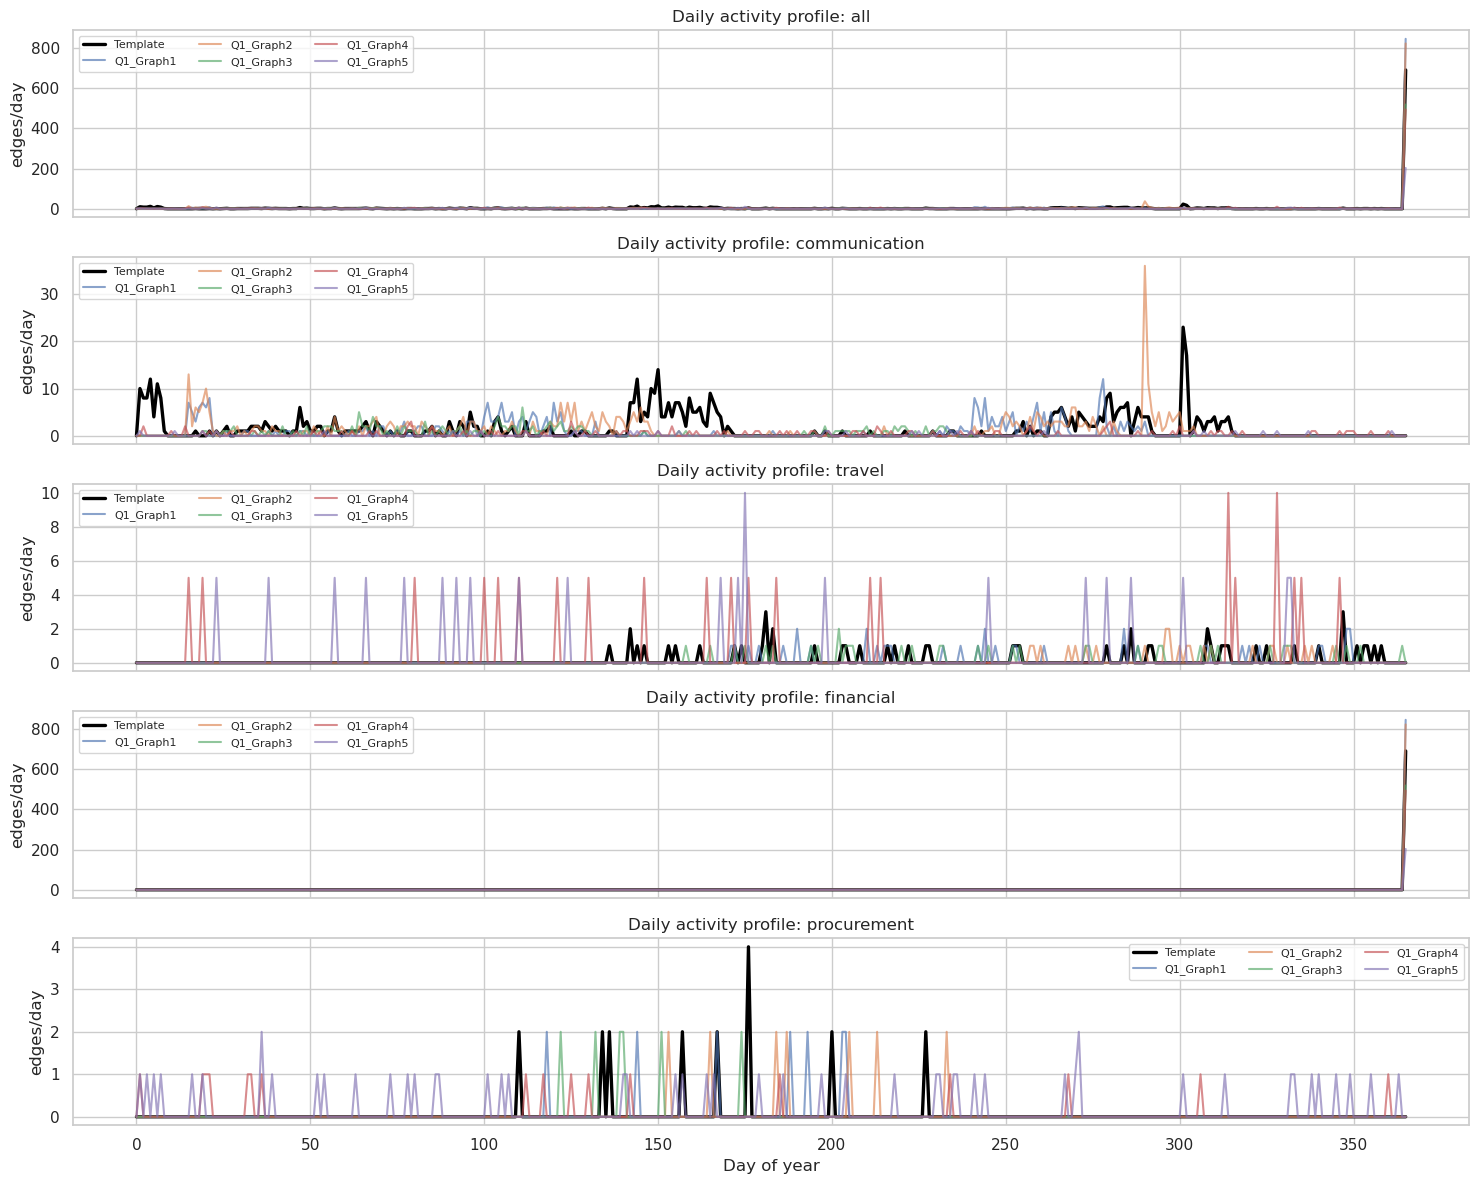

In [10]:
fig, axes = plt.subplots(len(LAYERS), 1, figsize=(15, 12), sharex=True)
for ax, (layer, etypes) in zip(axes, LAYERS.items()):
    for name, df in graphs.items():
        arr = daily_counts(df, etypes)
        if name == 'Template':
            ax.plot(arr, label=name, linewidth=2.4, color='black')
        else:
            ax.plot(arr, label=name, alpha=0.65)
    ax.set_title(f'Daily activity profile: {layer}')
    ax.set_ylabel('edges/day')
    ax.legend(ncol=3, fontsize=8)
axes[-1].set_xlabel('Day of year')
plt.tight_layout()
plt.show()

## 6. Financial, Travel, and Procurement Profile Comparison

The paper uses demographics, travel itineraries, and graphlet patterns for node matching.

In this reduced data subset, direct template category IDs cannot be compared with Q1 category IDs because template IDs are anonymized/local. Therefore, this EDA compares:

- sorted financial profile shapes,
- per-person financial vector shapes,
- travel vector shapes,
- buy/sell product profile shapes.

Lower distances indicate a closer match to the template.

In [11]:
def sorted_weight_profile(df, etype):
    sub = df[(df['eType'] == etype) & (df['Weight'] >= 0)]
    vals = sub.groupby('Target')['Weight'].sum().sort_values(ascending=False).to_numpy(dtype=float)
    return vals / vals.sum() if vals.sum() else vals


def person_profile_matrix(df, etype):
    sub = df[(df['eType'] == etype) & (df['Weight'] >= 0)]
    mat = sub.pivot_table(index='Source', columns='Target', values='Weight', aggfunc='sum', fill_value=0)
    if mat.empty:
        return np.array([])
    arr = np.sort(mat.to_numpy(dtype=float), axis=1)[:, ::-1]
    row_sums = arr.sum(axis=1, keepdims=True)
    return np.divide(arr, row_sums, out=np.zeros_like(arr), where=row_sums != 0)


def average_nearest_profile_distance(template_matrix, candidate_matrix):
    if template_matrix.size == 0 or candidate_matrix.size == 0:
        return 1.0
    distances = []
    for template_row in template_matrix:
        distances.append(min(cosine_distance(template_row, candidate_row) for candidate_row in candidate_matrix))
    return float(np.mean(distances))

template_financial_shape = sorted_weight_profile(graphs['Template'], 5)
template_buy_shape = sorted_weight_profile(graphs['Template'], 3)
template_sell_shape = sorted_weight_profile(graphs['Template'], 2)
template_person_financial = person_profile_matrix(graphs['Template'], 5)
template_person_travel = person_profile_matrix(graphs['Template'], 6)

profile_rows = []
for name, df in graphs.items():
    profile_rows.append({
        'graph': name,
        'financial_shape_distance': cosine_distance(template_financial_shape, sorted_weight_profile(df, 5)),
        'buy_shape_distance': cosine_distance(template_buy_shape, sorted_weight_profile(df, 3)),
        'sell_shape_distance': cosine_distance(template_sell_shape, sorted_weight_profile(df, 2)),
        'person_financial_nearest_distance': average_nearest_profile_distance(template_person_financial, person_profile_matrix(df, 5)),
        'person_travel_nearest_distance': average_nearest_profile_distance(template_person_travel, person_profile_matrix(df, 6)),
    })

profile_df = pd.DataFrame(profile_rows)
profile_df.sort_values('financial_shape_distance')

,graph,financial_shape_distance,buy_shape_distance,sell_shape_distance,person_financial_nearest_distance,person_travel_nearest_distance
0,Template,0.000000,0.000000,0.000000,8.540177e-18,2.081668e-17
3,Q1_Graph3,0.005892,0.000000,0.000000,1.064474e-02,1.043420e-02
4,Q1_Graph4,0.021093,0.162899,0.160952,1.059744e-02,2.312287e-02
2,Q1_Graph2,0.039781,0.000000,0.000000,9.643827e-03,1.537608e-02
1,Q1_Graph1,0.053237,0.000000,0.000000,9.271545e-03,1.119692e-02
5,Q1_Graph5,0.322492,0.478757,0.028178,1.535775e-02,5.251276e-02


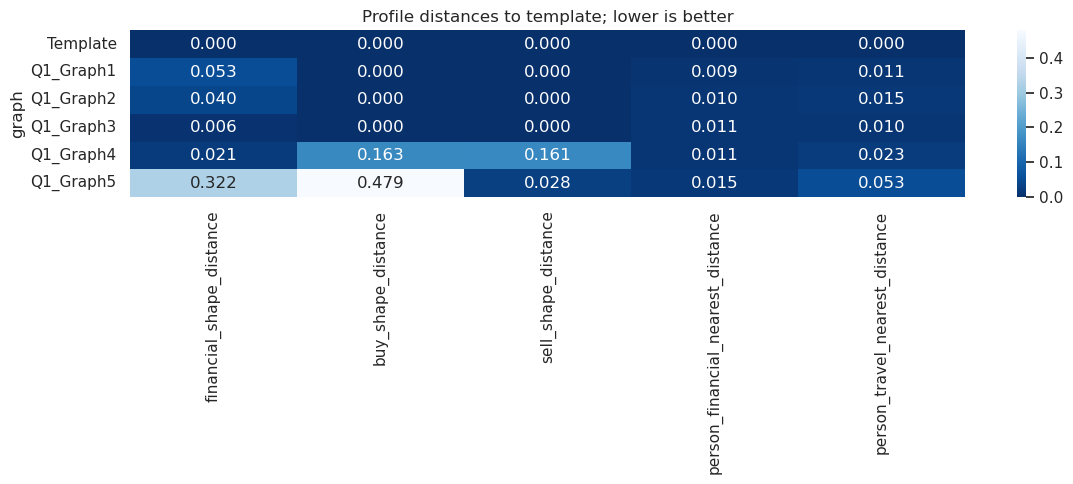

In [12]:
plt.figure(figsize=(12, 5))
plot_cols = [c for c in profile_df.columns if c != 'graph']
sns.heatmap(profile_df.set_index('graph')[plot_cols], annot=True, fmt='.3f', cmap='Blues_r')
plt.title('Profile distances to template; lower is better')
plt.tight_layout()
plt.show()

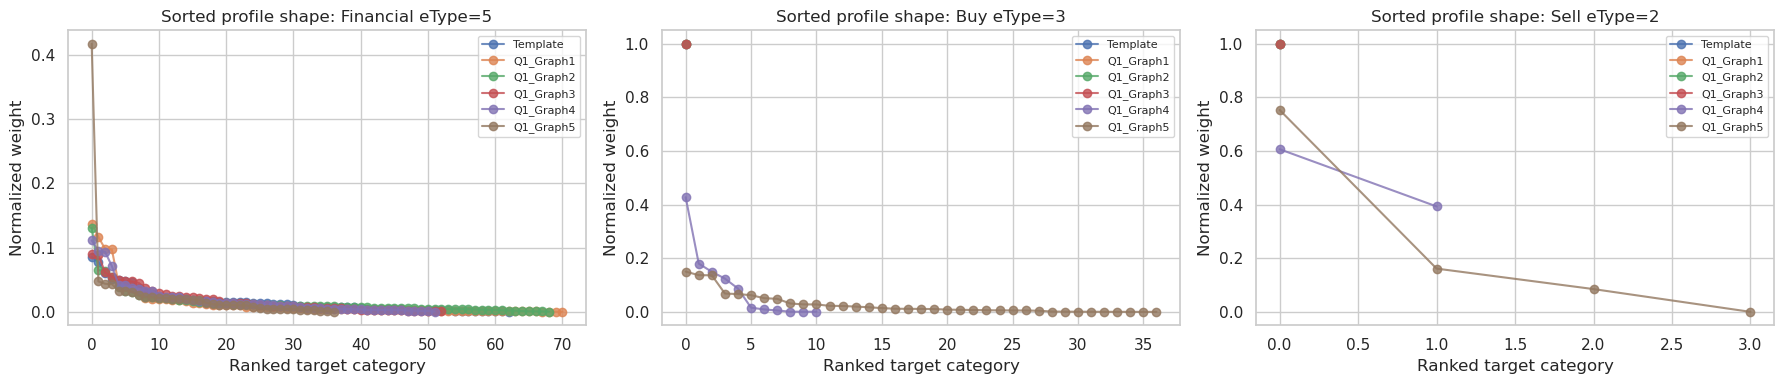

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, etype, title in zip(axes, [5, 3, 2], ['Financial eType=5', 'Buy eType=3', 'Sell eType=2']):
    for name, df in graphs.items():
        profile = sorted_weight_profile(df, etype)
        ax.plot(profile, marker='o', linewidth=1.5, label=name, alpha=0.8)
    ax.set_title(f'Sorted profile shape: {title}')
    ax.set_xlabel('Ranked target category')
    ax.set_ylabel('Normalized weight')
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 7. Q2 Seed Inspection

The PDF describes seed-based matching: start from the person in a seeding edge, expand to immediate neighbors, score candidate persons, and greedily build a matched subgraph.

Here, the Q2 seed files contain only one edge each. This section checks the node types and whether those edges or nodes appear in the available Q1 candidate subsets.

In [14]:
q1_node_sets = {name: set(map(str, graph_node_ids(df))) for name, df in graphs.items() if name != 'Template'}
q1_edge_sets = {
    name: set(zip(df['Source'].astype(str), df['Target'].astype(str), df['eType'].astype(int)))
    for name, df in graphs.items()
    if name != 'Template'
}

seed_rows = []
for seed_name, seed_df in seeds.items():
    row = seed_df.iloc[0].copy()
    source = str(row['Source'])
    target = str(row['Target'])
    etype = int(row['eType'])
    edge = (source, target, etype)
    seed_rows.append({
        'seed': seed_name,
        'source': source,
        'source_type': NODE_TYPE_LABELS.get(global_type_map.get(source), 'Unknown'),
        'target': target,
        'target_type': NODE_TYPE_LABELS.get(global_type_map.get(target), 'Unknown'),
        'eType': etype,
        'edge_label': EDGE_TYPE_LABELS.get(etype, str(etype)),
        'time': row['Time'],
        'weight': row['Weight'],
        'edge_in_q1_graphs': [name for name, edges in q1_edge_sets.items() if edge in edges],
        'source_in_q1_graphs': [name for name, nodes in q1_node_sets.items() if source in nodes],
        'target_in_q1_graphs': [name for name, nodes in q1_node_sets.items() if target in nodes],
    })

seed_summary_df = pd.DataFrame(seed_rows)
seed_summary_df

,seed,source,source_type,target,target_type,eType,edge_label,time,weight,edge_in_q1_graphs,source_in_q1_graphs,target_in_q1_graphs
0,Q2_Seed1,600971.0,Unknown,579269.0,Unknown,4,Author-of,-685755382.0,0.166667,[],[],[]
1,Q2_Seed2,538771.0,Unknown,473043.0,Unknown,4,Author-of,-623491200.0,0.090909,[],[],[]
2,Q2_Seed3,574136.0,Unknown,657187.0,Unknown,2,Sell,1991785.0,633.000000,[],[],[]


## 8. Combined Candidate Ranking

The final score combines the PDF-inspired evidence:

- graphlet frequency distance,
- all-edge temporal distance,
- communication temporal distance,
- travel temporal distance,
- financial profile shape distance,
- buy profile shape distance,
- sell profile shape distance,
- nearest per-person financial profile distance,
- nearest per-person travel profile distance.

Each metric is normalized by the maximum candidate value before averaging. Lower score means more similar to the template.

In [15]:
ranking = (
    graphlet_df[['graph', 'graphlet_l1_distance_to_template']]
    .merge(
        temporal_df.pivot(index='graph', columns='layer', values='cosine_distance_to_template')
        .rename(columns={
            'all': 'all_time_distance',
            'communication': 'communication_time_distance',
            'travel': 'travel_time_distance',
            'financial': 'financial_time_distance',
            'procurement': 'procurement_time_distance',
        })
        .reset_index(),
        on='graph'
    )
    .merge(profile_df, on='graph')
)

candidate_ranking = ranking[ranking['graph'] != 'Template'].copy()
score_metrics = [
    'graphlet_l1_distance_to_template',
    'all_time_distance',
    'communication_time_distance',
    'travel_time_distance',
    'financial_shape_distance',
    'buy_shape_distance',
    'sell_shape_distance',
    'person_financial_nearest_distance',
    'person_travel_nearest_distance',
]

for metric in score_metrics:
    max_value = candidate_ranking[metric].max()
    candidate_ranking[f'{metric}_norm'] = candidate_ranking[metric] / max_value if max_value else 0

candidate_ranking['pdf_methodology_score'] = candidate_ranking[[f'{m}_norm' for m in score_metrics]].mean(axis=1)

lag_table = temporal_df.pivot(index='graph', columns='layer', values='best_lag_days').reset_index().rename(columns={
    'all': 'all_lag_days',
    'communication': 'communication_lag_days',
    'travel': 'travel_lag_days',
})

candidate_ranking = candidate_ranking.merge(
    lag_table[['graph', 'all_lag_days', 'communication_lag_days', 'travel_lag_days']],
    on='graph',
    how='left'
)

candidate_ranking[[
    'graph',
    'pdf_methodology_score',
    'graphlet_l1_distance_to_template',
    'all_time_distance',
    'communication_time_distance',
    'travel_time_distance',
    'financial_shape_distance',
    'buy_shape_distance',
    'sell_shape_distance',
    'person_financial_nearest_distance',
    'person_travel_nearest_distance',
    'communication_lag_days',
    'travel_lag_days',
]].sort_values('pdf_methodology_score')

,graph,pdf_methodology_score,graphlet_l1_distance_to_template,all_time_distance,communication_time_distance,travel_time_distance,financial_shape_distance,buy_shape_distance,sell_shape_distance,person_financial_nearest_distance,person_travel_nearest_distance,communication_lag_days,travel_lag_days
1,Q1_Graph2,0.377760,0.237415,0.004966,0.410951,0.710467,0.039781,0.000000,0.000000,0.009644,0.015376,11,16
0,Q1_Graph1,0.394147,0.307590,0.004391,0.511670,0.730626,0.053237,0.000000,0.000000,0.009272,0.011197,24,-9
2,Q1_Graph3,0.406191,0.284830,0.004329,0.722222,0.694112,0.005892,0.000000,0.000000,0.010645,0.010434,28,2
3,Q1_Graph4,0.649018,0.624083,0.004937,0.674750,0.705154,0.021093,0.162899,0.160952,0.010597,0.023123,22,19
4,Q1_Graph5,0.888445,0.512328,0.009731,0.776219,0.759437,0.322492,0.478757,0.028178,0.015358,0.052513,-6,6


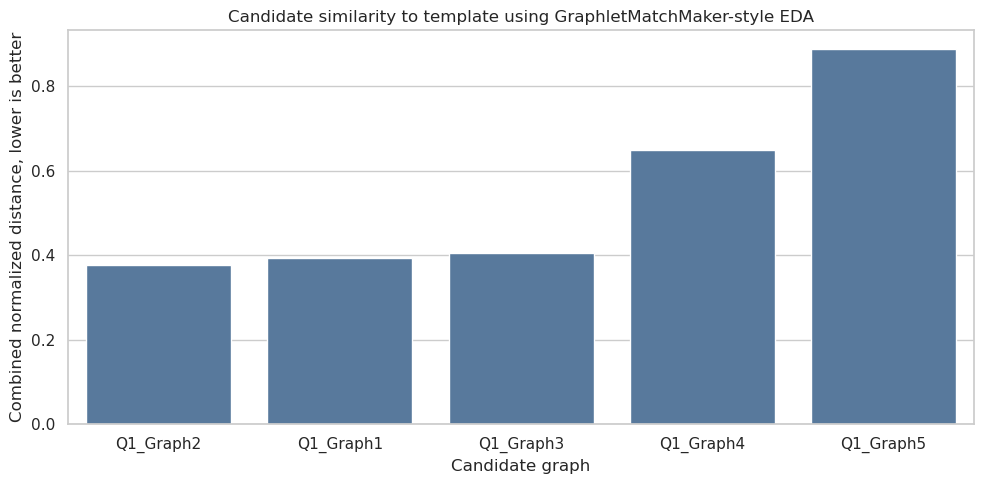

In [16]:
plt.figure(figsize=(10, 5))
ordered = candidate_ranking.sort_values('pdf_methodology_score')
sns.barplot(data=ordered, x='graph', y='pdf_methodology_score', color='#4C78A8')
plt.title('Candidate similarity to template using GraphletMatchMaker-style EDA')
plt.xlabel('Candidate graph')
plt.ylabel('Combined normalized distance, lower is better')
plt.tight_layout()
plt.show()

## 9. Main Conclusion

Using the methodology from `GraphletMatchMaker.pdf`, `Q1_Graph2` is the best overall match to `CGCS-Template`.

The evidence is strongest in the person-to-person graphlet structure, communication temporal profile, and profile-shape metrics. `Q1_Graph1` and `Q1_Graph3` are close alternatives, while `Q1_Graph4` and `Q1_Graph5` are substantially less similar due to different communication structures and profile distributions.